In [1]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize, curve_fit
from emcee import EnsembleSampler

import matplotlib.pyplot as plt

In [2]:
#read in data, fix columns
df = (pd.read_csv("polarizer_correlation.csv")
      .drop(columns=['Trial Number', 'Angle A'])
      .rename(columns={
          "Angle B": "ANGLE",
          "N_coin / time": "COIN_RATE",
          "TIME [s]": "TIME"
      }))
df['E_N_COIN'] = np.sqrt(df['N_COIN'])
df['E_COIN_RATE'] = df['E_N_COIN'] / df['TIME']
df

,ANGLE,N_A,N_B,N_COIN,TIME,COIN_RATE,E_N_COIN,E_COIN_RATE
0,0.0,NaN,NaN,14340,10.00077,1433.889591,119.749739,11.974052
1,22.5,NaN,NaN,13079,9.99107,1309.068999,114.363456,11.446567
2,30.0,NaN,NaN,11696,9.99126,1170.623125,108.148047,10.824265
3,45.0,NaN,NaN,8637,10.00051,863.655954,92.935461,9.293072
4,60.0,NaN,NaN,5221,9.99106,522.567175,72.256488,7.232114
5,67.5,NaN,NaN,3204,10.00011,320.396476,56.603887,5.660326
6,90.0,NaN,NaN,1333,9.98170,133.544386,36.510273,3.657721
7,100.0,NaN,NaN,1651,9.98067,165.419756,40.632499,4.071119
8,112.5,NaN,NaN,3362,10.00016,336.194621,57.982756,5.798183
9,120.0,NaN,NaN,4630,9.98259,463.807489,68.044103,6.816277


In [3]:
#plot settings
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{amsmath}"
})
plt.rcParams["font.size"] = 15

In [4]:
def model(x, phase, amplitude, baseline):
    x = np.array(x)
    y = amplitude * np.cos(x * np.pi / 90 + phase * np.pi/180) + baseline
    return y

In [5]:
def chi_sq(theta, uncertainty_multiplier = 1):
    y_mod = model(df["ANGLE"], *theta)
    y_data = df["COIN_RATE"]
    return np.sum((y_data - y_mod)**2/(df['E_COIN_RATE'] * uncertainty_multiplier)**2) / len(df - len(theta))

In [6]:
p0 = [0, 750, 750]
pcurve_fit, ecurve_fit = curve_fit(model, df['ANGLE'], df['COIN_RATE'], p0)

7.842911213075417


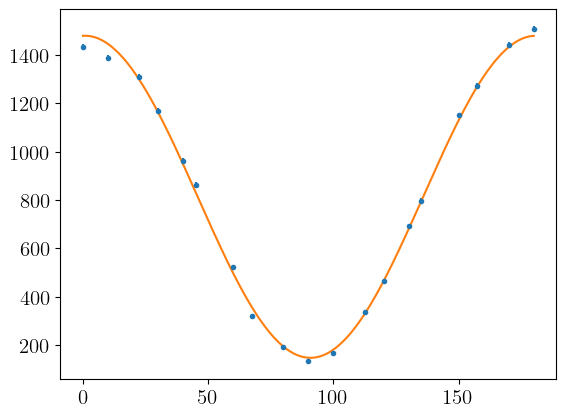

In [7]:
plt.errorbar(df["ANGLE"], df["COIN_RATE"], df['E_COIN_RATE'], ls='', marker='.')
x = np.linspace(0, 180, 1000)
plt.plot(x, model(x, *pcurve_fit))
print(chi_sq(pcurve_fit))

In [8]:
#mcmc prior
def log_prior(theta):
    if np.any(theta[1:] < 0):
        return -np.inf
    return 0

#mcmc log likelihood
def log_prob(theta):
    if log_prior(theta) == -np.inf:
        return -np.inf
    
    y_mod = model(df['ANGLE'], *theta)
    y_real = df['COIN_RATE']
    return np.sum(-(y_mod - y_real)**2/df['E_COIN_RATE']**2)

In [9]:
#initialize mcmc walkers
N_WALKERS = 16
BUMP_SIZE = 1
x0 = pcurve_fit + BUMP_SIZE * np.random.randn(N_WALKERS, len(pcurve_fit))

In [10]:
#run mcmc
from multiprocessing import Pool, cpu_count

with Pool(cpu_count()) as p:
    sampler = EnsembleSampler(N_WALKERS, x0.shape[1], log_prob, pool=p)
    sampler.run_mcmc(x0, 10000, progress=True)

100%|██████████| 10000/10000 [01:20<00:00, 124.97it/s]


In [11]:
#names of parameters
param_labels = [
    "Phase",
    "Amplitude",
    "Baseline"
]

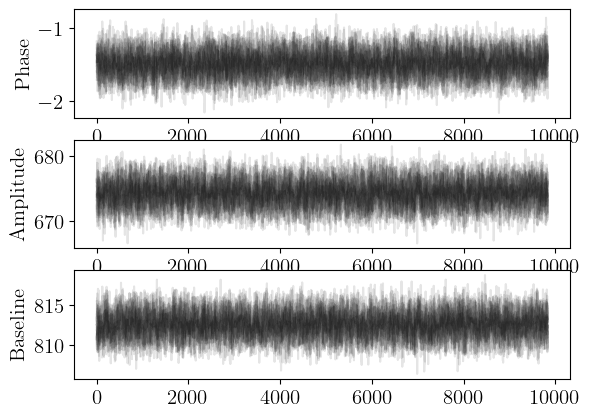

In [12]:
#check fit stability 
autocorr_time = sampler.get_autocorr_time()
chain = sampler.get_chain(discard=int(np.max(autocorr_time*4)))
for dim_n in range(chain.shape[2]):
    ax = plt.subplot(chain.shape[2], 1, dim_n + 1)
    ax.set_ylabel(param_labels[dim_n])
    for walker_n in range(chain.shape[1]):
        plt.plot(chain[:, walker_n, dim_n], c='black', alpha=0.1)

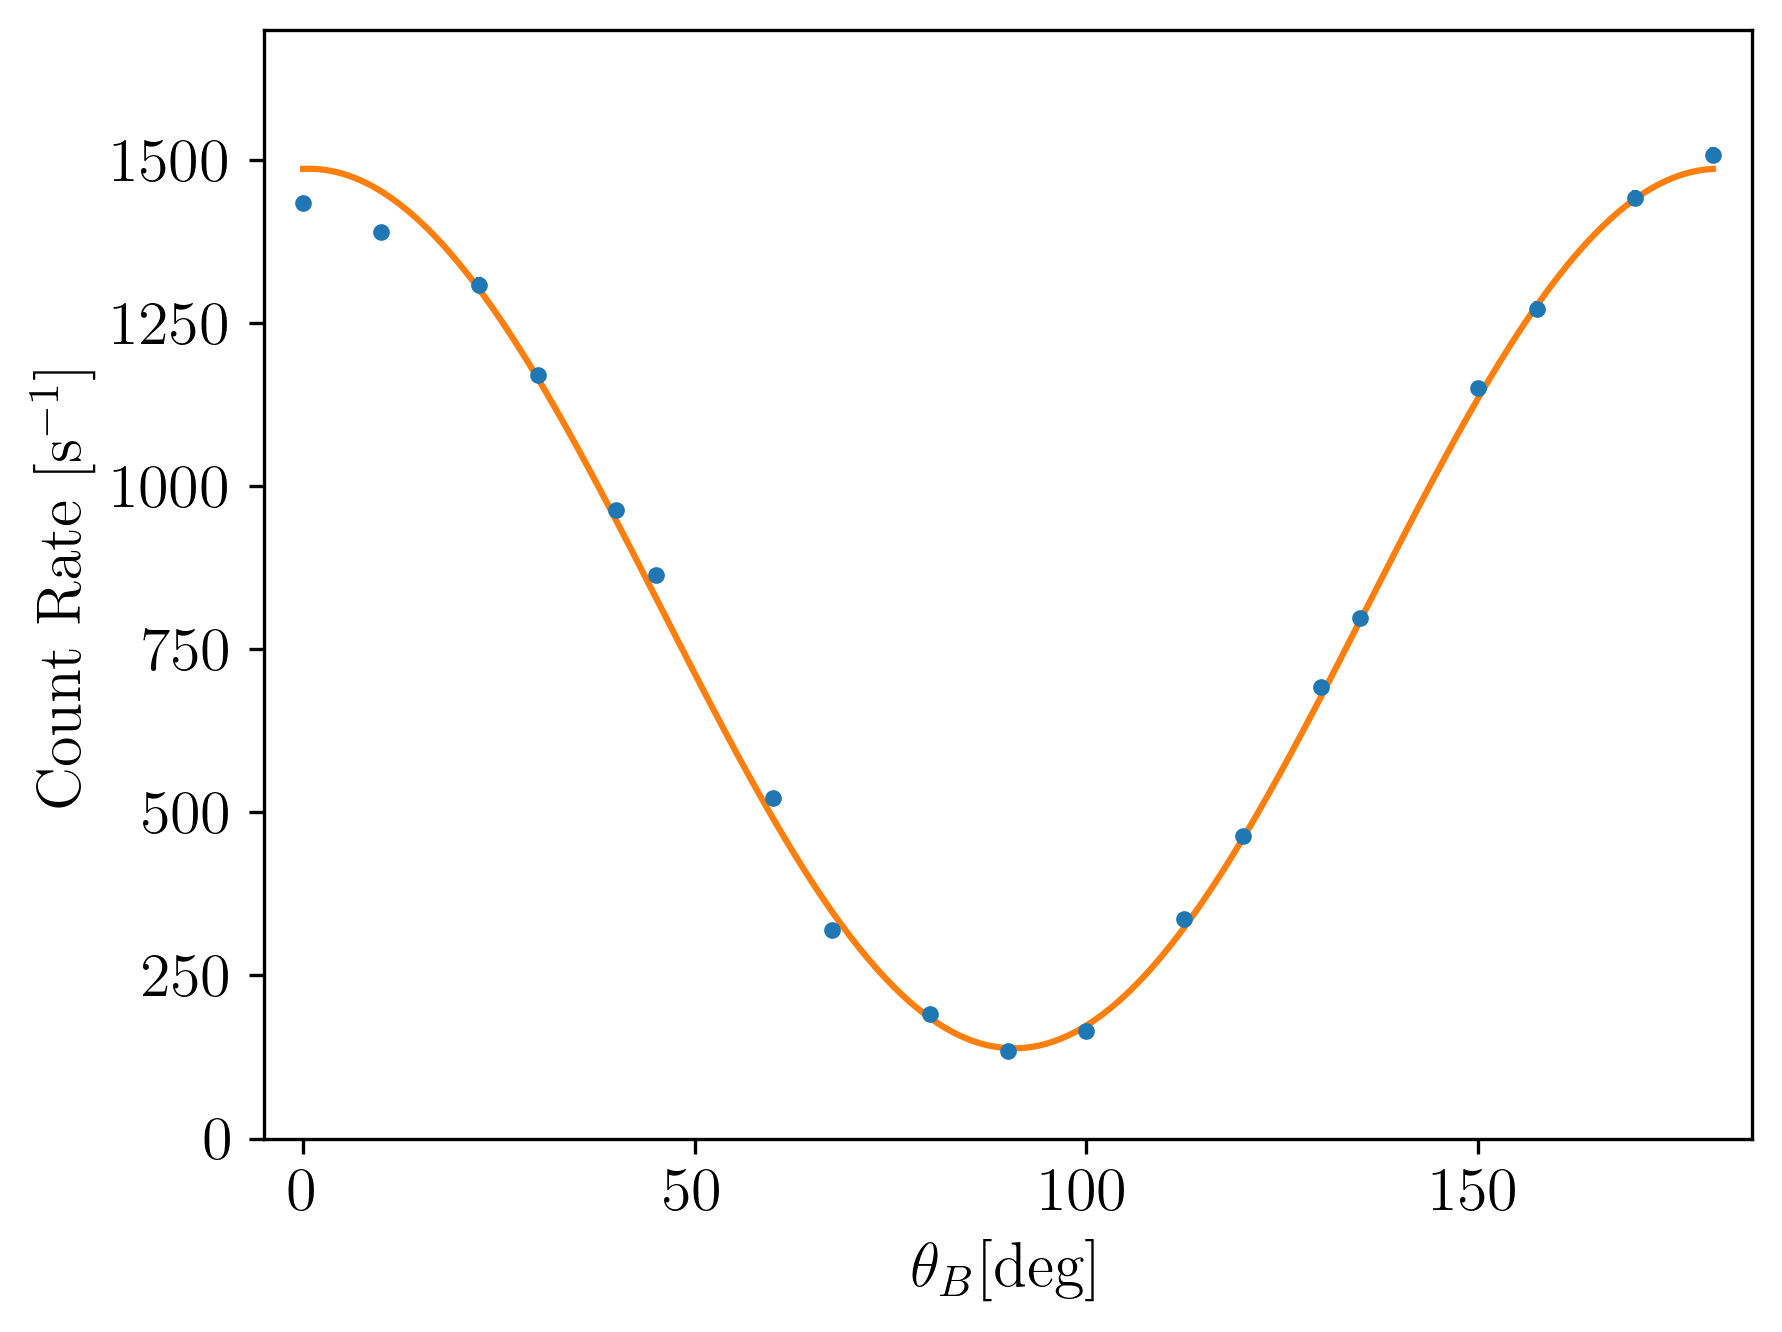

In [13]:
chain = sampler.get_chain(discard=int(np.max(autocorr_time*4)), flat=True)
fig, ax = plt.subplots(dpi = 300)

ax.errorbar(df['ANGLE'], df['COIN_RATE'], df["E_COIN_RATE"], ls="", marker=".")
x = np.linspace(0, 180, 500)
ax.plot(x, model(x, *np.median(chain, axis = 0)))

ax.set_ylim(0, 1700)
ax.set_xlim(-5, 185)

ax.set_xlabel("$\\theta_B [\\text{deg}]$")
ax.set_ylabel("Count Rate $[\\text{s}^{-1}]$")
plt.savefig("figures/mcmc_polarizer_fit.png", bbox_inches = "tight")

In [14]:
df

,ANGLE,N_A,N_B,N_COIN,TIME,COIN_RATE,E_N_COIN,E_COIN_RATE
0,0.0,NaN,NaN,14340,10.00077,1433.889591,119.749739,11.974052
1,22.5,NaN,NaN,13079,9.99107,1309.068999,114.363456,11.446567
2,30.0,NaN,NaN,11696,9.99126,1170.623125,108.148047,10.824265
3,45.0,NaN,NaN,8637,10.00051,863.655954,92.935461,9.293072
4,60.0,NaN,NaN,5221,9.99106,522.567175,72.256488,7.232114
5,67.5,NaN,NaN,3204,10.00011,320.396476,56.603887,5.660326
6,90.0,NaN,NaN,1333,9.98170,133.544386,36.510273,3.657721
7,100.0,NaN,NaN,1651,9.98067,165.419756,40.632499,4.071119
8,112.5,NaN,NaN,3362,10.00016,336.194621,57.982756,5.798183
9,120.0,NaN,NaN,4630,9.98259,463.807489,68.044103,6.816277


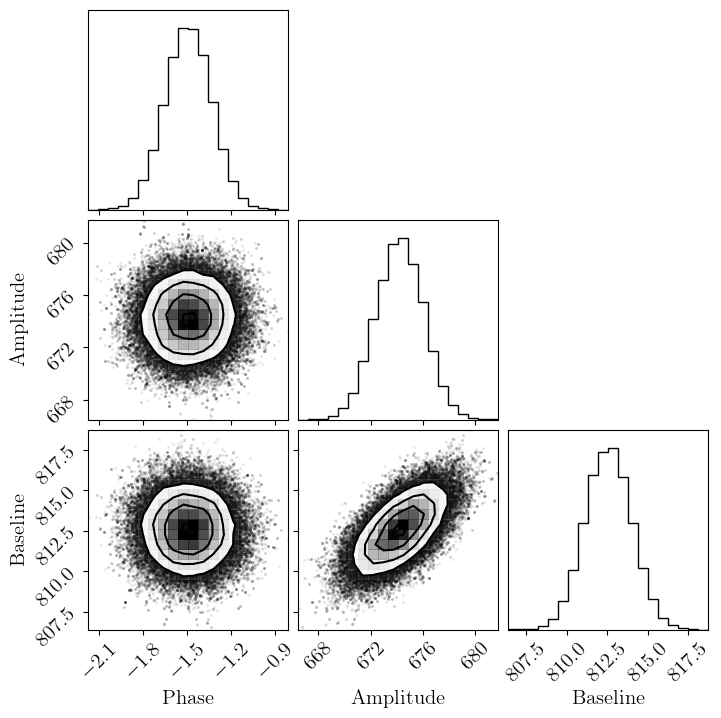

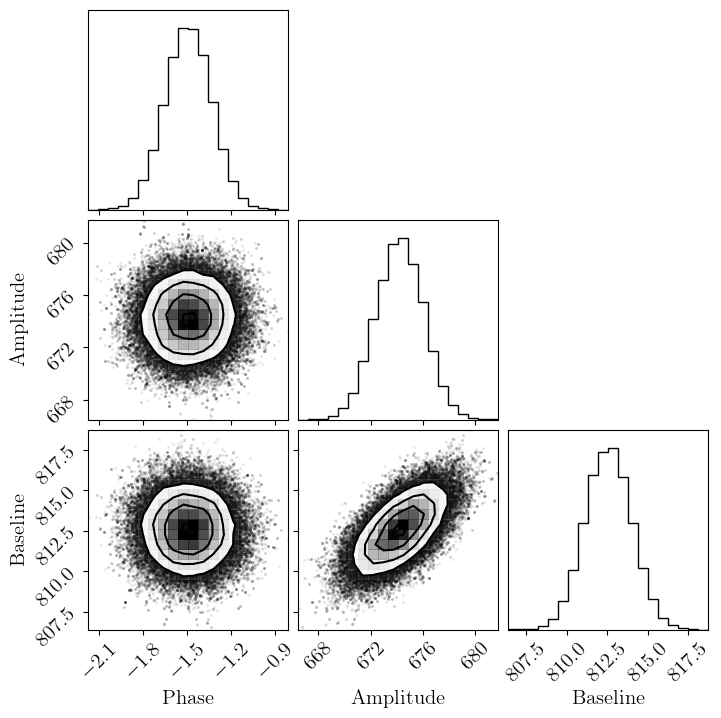

In [15]:
#examine posterior distributions of parameters
import corner
corner.corner(sampler.get_chain(discard=int(np.max(autocorr_time*4)), flat=True), labels=param_labels)

In [16]:
chain = sampler.get_chain(flat=True, discard=int(np.max(autocorr_time*4)))
results = pd.DataFrame(
    {
        "Median Value": np.median(chain, axis = 0),
        "Uncertainty": np.sqrt(np.diag(np.cov(chain.T))),
        "2-sigma Uncertainty": np.sqrt(np.diag(np.cov(chain.T))) * 2
    },
    index=param_labels
)
results["Uncertainty/Value"] = results["2-sigma Uncertainty"]/results["Median Value"]

In [17]:

results.to_csv("mcmc_fit.csv")
results

,Median Value,Uncertainty,2-sigma Uncertainty,Uncertainty/Value
Phase,-1.490811,0.157614,0.315229,-0.211448
Amplitude,674.243304,1.809308,3.618616,0.005367
Baseline,812.592449,1.432979,2.865958,0.003527


In [18]:
chi_sq_mcmc = chi_sq(np.median(chain, axis = 0))
chi_sq_mcmc
#quite high, will try rescaling errors 

6.789472591925211

In [19]:
#mcmc log likelihood
def log_prob_adjusted(theta):
    if log_prior(theta) == -np.inf:
        return -np.inf
    
    y_mod = model(df['ANGLE'], *theta)
    y_real = df['COIN_RATE']
    return np.sum(-(y_mod - y_real)**2/(df['E_COIN_RATE'] * np.sqrt(chi_sq_mcmc))**2)

In [20]:
#initialize mcmc walkers
N_WALKERS = 16
BUMP_SIZE = 1
x0 = pcurve_fit + BUMP_SIZE * np.random.randn(N_WALKERS, len(pcurve_fit))

In [21]:
#run mcmc
sampler = EnsembleSampler(N_WALKERS, x0.shape[1], log_prob_adjusted)
sampler.run_mcmc(x0, 10000, progress=True)

100%|██████████| 10000/10000 [00:45<00:00, 221.78it/s]


State([[-1.19685287e+00  6.68431374e+02  8.17239409e+02]
 [-1.61447361e+00  6.70392260e+02  8.03124804e+02]
 [-2.03454856e+00  6.76137929e+02  8.11873440e+02]
 [-1.38722417e+00  6.73291329e+02  8.13941610e+02]
 [-1.42745079e+00  6.77115294e+02  8.12207694e+02]
 [-1.72977817e+00  6.83521286e+02  8.13992247e+02]
 [-1.76520976e+00  6.69284959e+02  8.12915908e+02]
 [-1.28111420e+00  6.74423994e+02  8.12994028e+02]
 [-1.73377769e+00  6.71757755e+02  8.08585848e+02]
 [-6.86685205e-01  6.64547649e+02  8.08911255e+02]
 [-2.08537026e+00  6.74003617e+02  8.14413879e+02]
 [-1.68211642e+00  6.73150055e+02  8.17683089e+02]
 [-1.64523567e+00  6.67803598e+02  8.09233617e+02]
 [-1.37772590e+00  6.82269445e+02  8.18508879e+02]
 [-1.56965010e+00  6.78696147e+02  8.21259121e+02]
 [-2.21218718e+00  6.72268734e+02  8.07621785e+02]], log_prob=[-23.38192868 -22.76230791 -20.13612715 -19.24483389 -19.39627664
 -21.77941312 -20.20937133 -19.13643312 -19.77665956 -23.18581939
 -20.23919795 -20.96079609 -20.0127

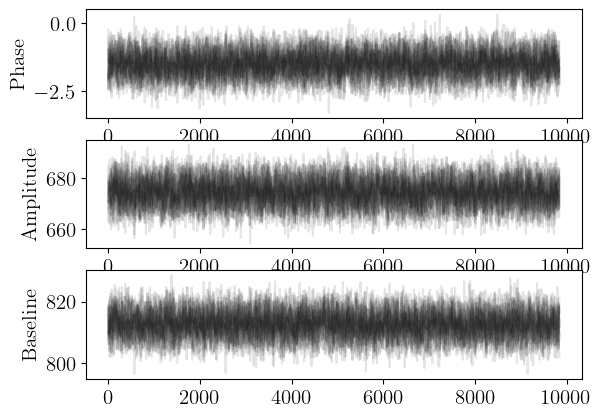

In [22]:
#check fit stability 
autocorr_time = sampler.get_autocorr_time()
chain = sampler.get_chain(discard=int(np.max(autocorr_time*4)))
for dim_n in range(chain.shape[2]):
    ax = plt.subplot(chain.shape[2], 1, dim_n + 1)
    ax.set_ylabel(param_labels[dim_n])
    for walker_n in range(chain.shape[1]):
        plt.plot(chain[:, walker_n, dim_n], c='black', alpha=0.1)

1.0000097153563663


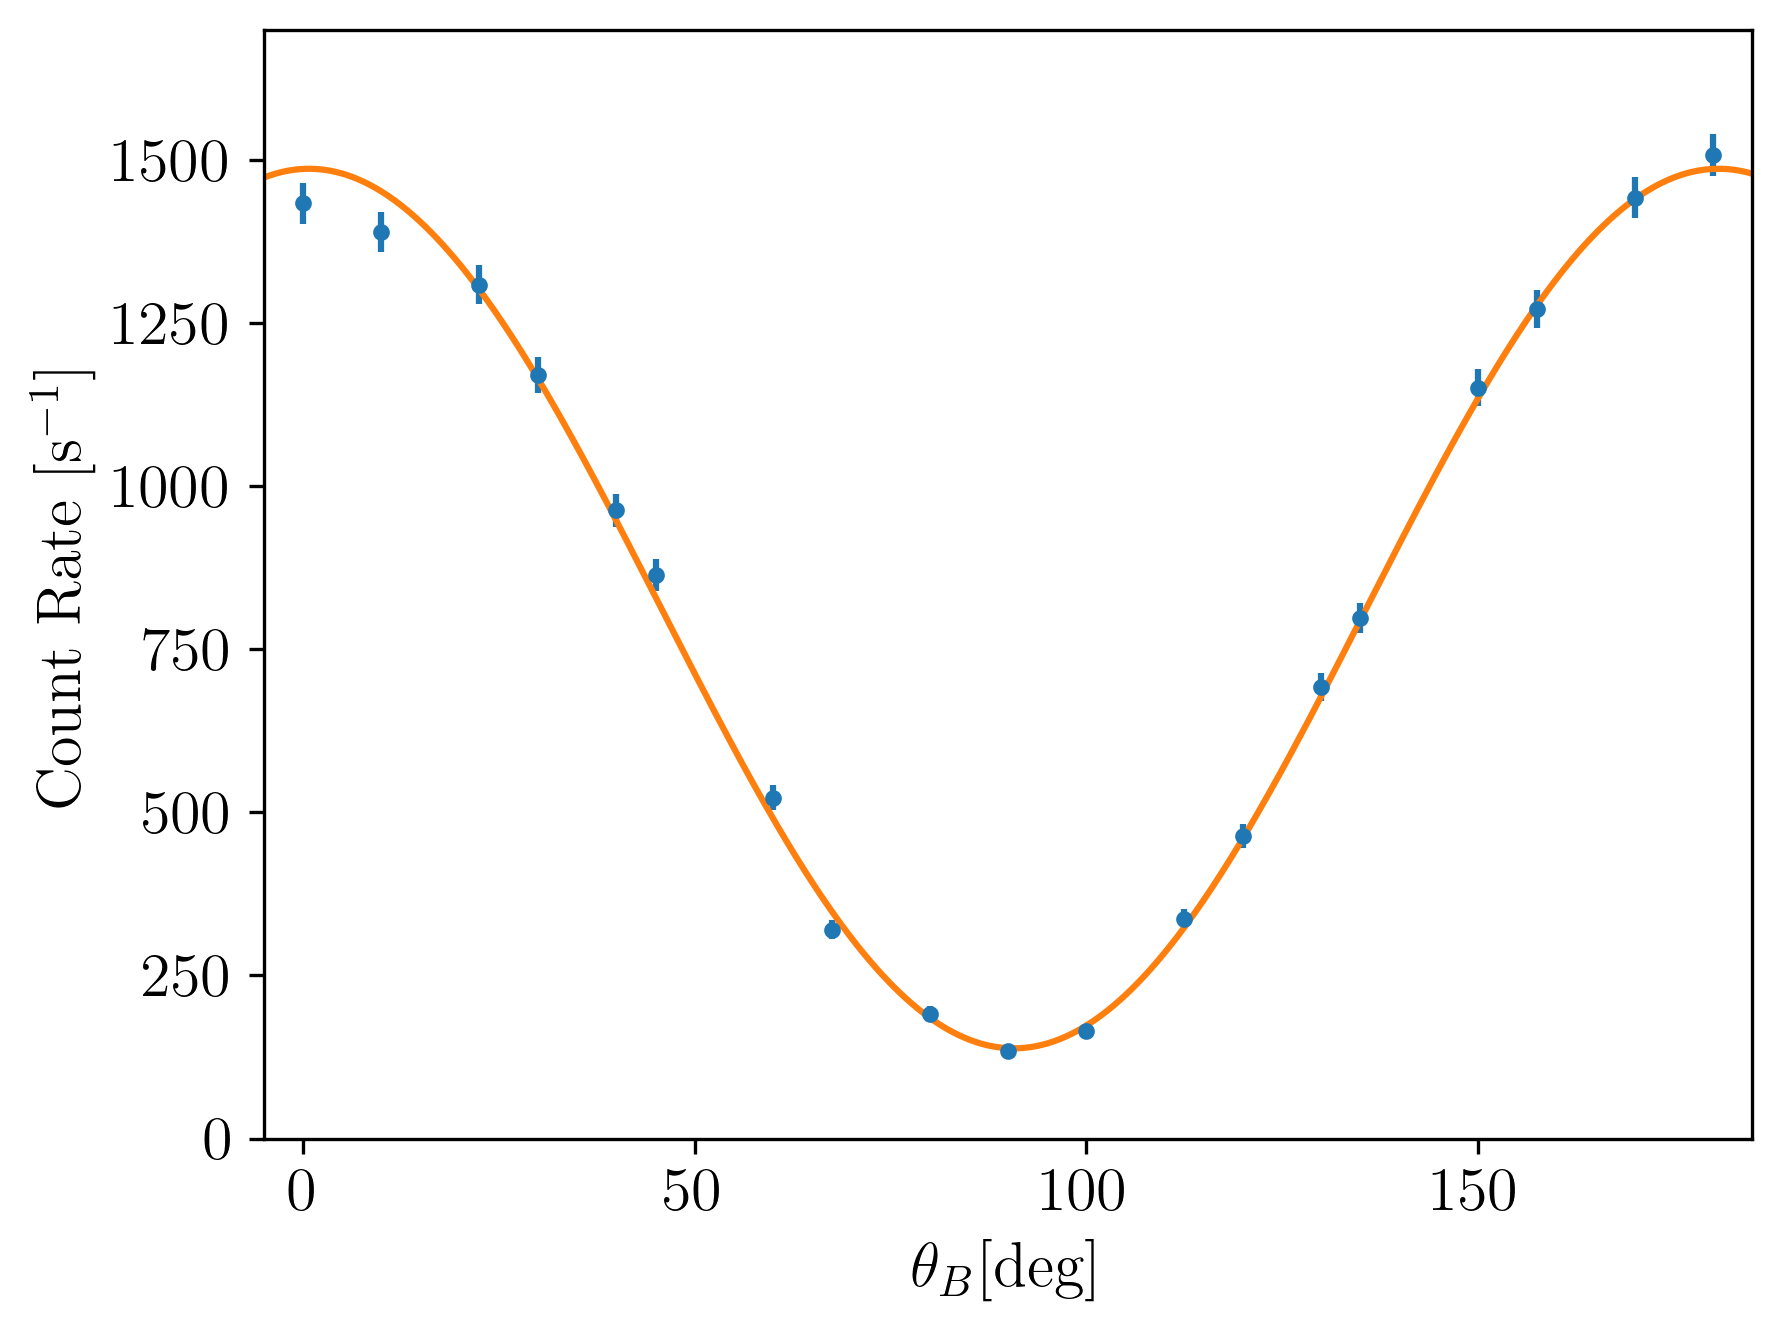

In [23]:
chain = sampler.get_chain(discard=int(np.max(autocorr_time*4)), flat=True)
fig, ax = plt.subplots(dpi = 300)

ax.errorbar(df['ANGLE'], df['COIN_RATE'], df["E_COIN_RATE"] * np.sqrt(chi_sq_mcmc), ls="", marker=".")
x = np.linspace(-5, 185, 500)
ax.plot(x, model(x, *np.median(chain, axis = 0)))

ax.set_ylim(0, 1700)
ax.set_xlim(-5, 185)
ax.set_xlabel("$\\theta_B [\\text{deg}]$")
ax.set_ylabel("Count Rate $[\\text{s}^{-1}]$")
plt.savefig("figures/mcmc_polarizer_fit_adjusted_sigma.png", bbox_inches = "tight")
#new chi sq
print(chi_sq(np.median(chain, axis = 0), np.sqrt(chi_sq_mcmc)))

In [24]:
chain = sampler.get_chain(flat=True, discard=int(np.max(autocorr_time*4)))
results = pd.DataFrame(
    {
        "Median Value": np.median(chain, axis = 0),
        "Uncertainty": np.sqrt(np.diag(np.cov(chain.T))),
        "2-sigma Uncertainty": np.sqrt(np.diag(np.cov(chain.T))) * 2
    },
    index=param_labels
)
results["Uncertainty/Value"] = results["2-sigma Uncertainty"]/results["Median Value"]

In [25]:
results.to_csv("mcmc_fit_adjusted.csv")
results

,Median Value,Uncertainty,2-sigma Uncertainty,Uncertainty/Value
Phase,-1.483247,0.406798,0.813595,-0.548523
Amplitude,674.257011,4.690263,9.380526,0.013912
Baseline,812.606288,3.737179,7.474359,0.009198


1.0000097153563663


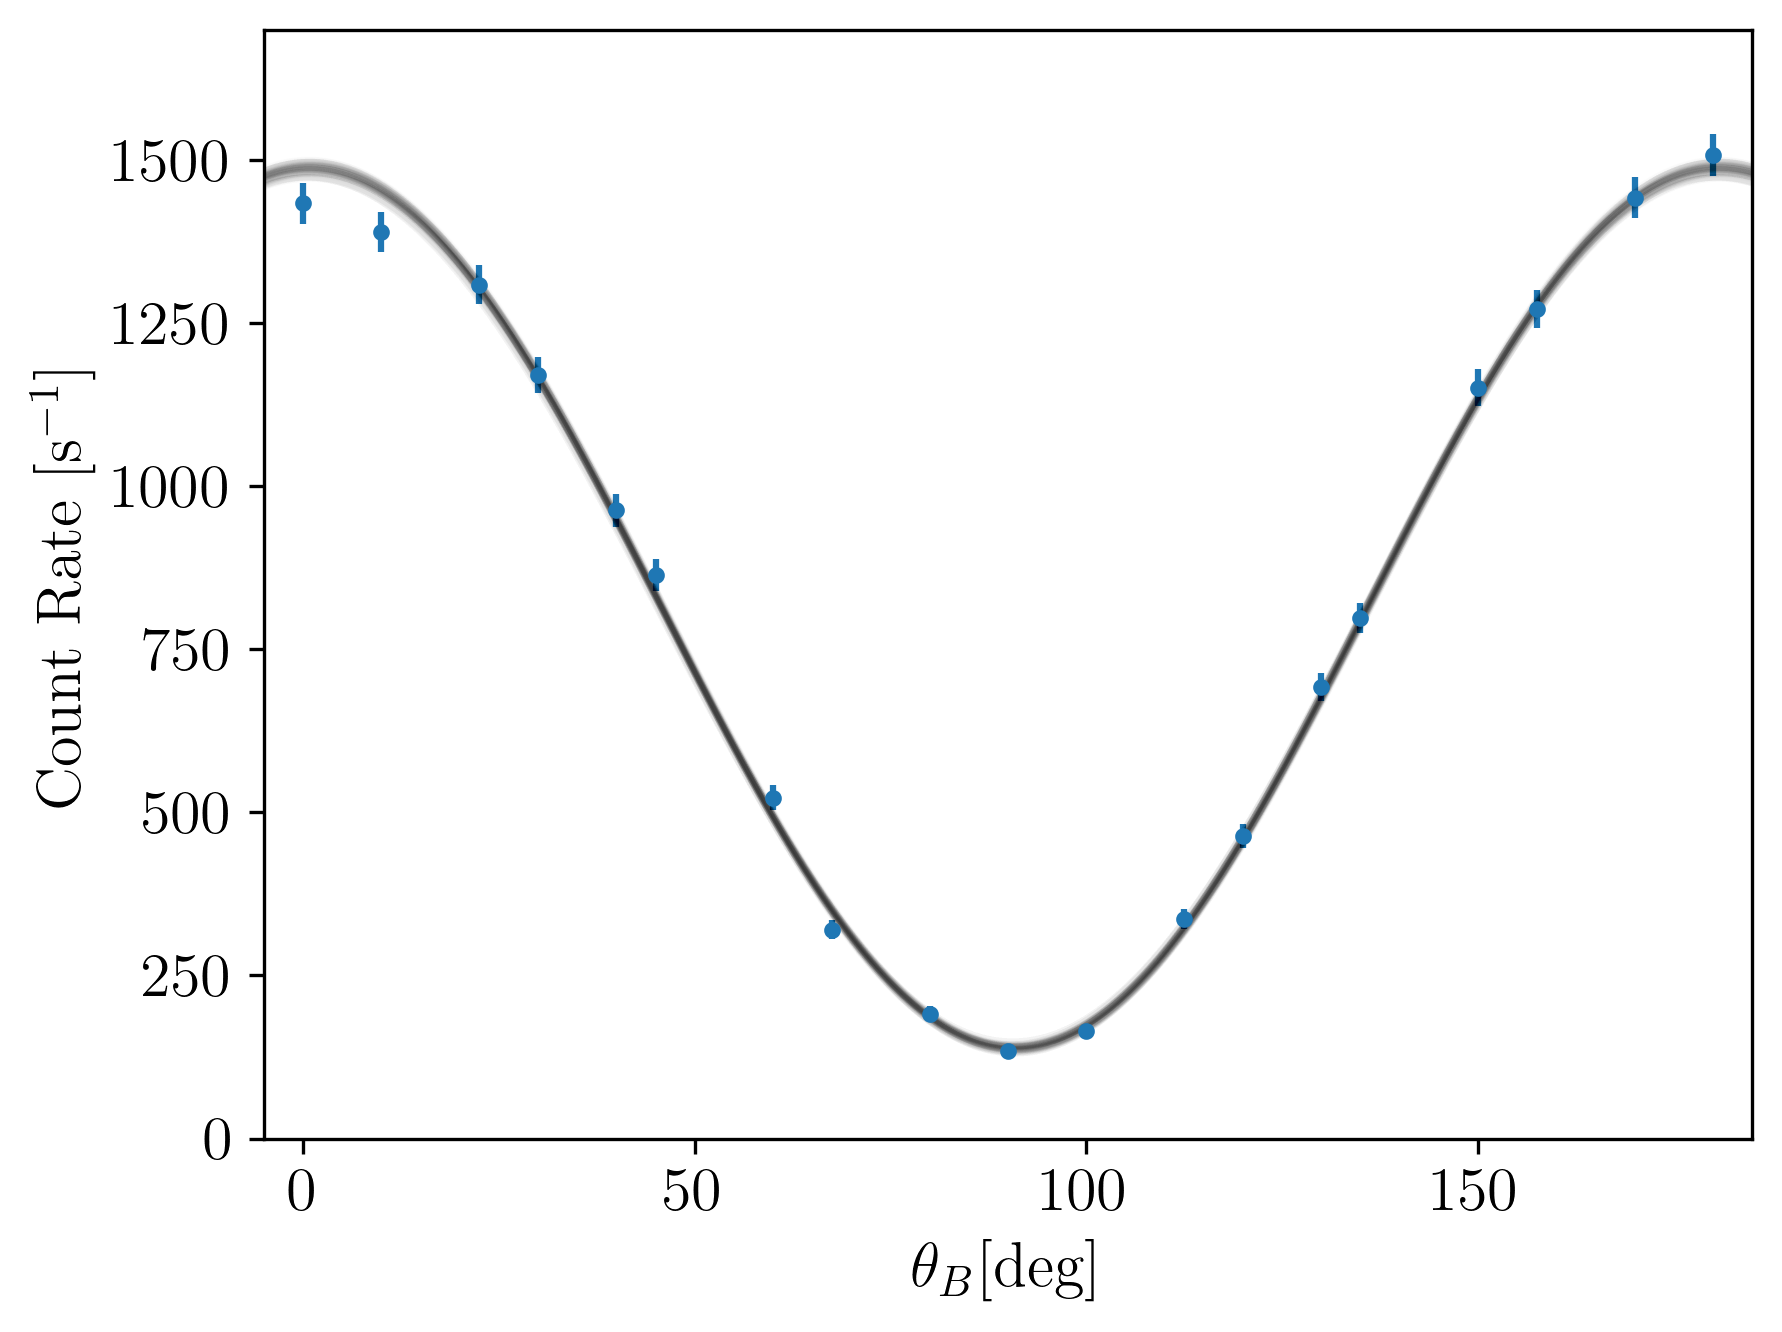

In [26]:
chain = sampler.get_chain(discard=int(np.max(autocorr_time*4)), flat=True)
fig, ax = plt.subplots(dpi = 300)

ax.errorbar(df['ANGLE'], df['COIN_RATE'], df["E_COIN_RATE"] * np.sqrt(chi_sq_mcmc), ls="", marker=".")
x = np.linspace(-5, 185, 500)
#ax.plot(x, model(x, *np.median(chain, axis = 0)))
for i in range(100):
    ax.plot(x, model(x, *chain[-i]), color = "black", alpha = 0.01)
ax.set_ylim(0, 1700)
ax.set_xlim(-5, 185)
ax.set_xlabel("$\\theta_B [\\text{deg}]$")
ax.set_ylabel("Count Rate $[\\text{s}^{-1}]$")
plt.savefig("figures/density_plot.png", bbox_inches = "tight")
#new chi sq
print(chi_sq(np.median(chain, axis = 0), np.sqrt(chi_sq_mcmc)))

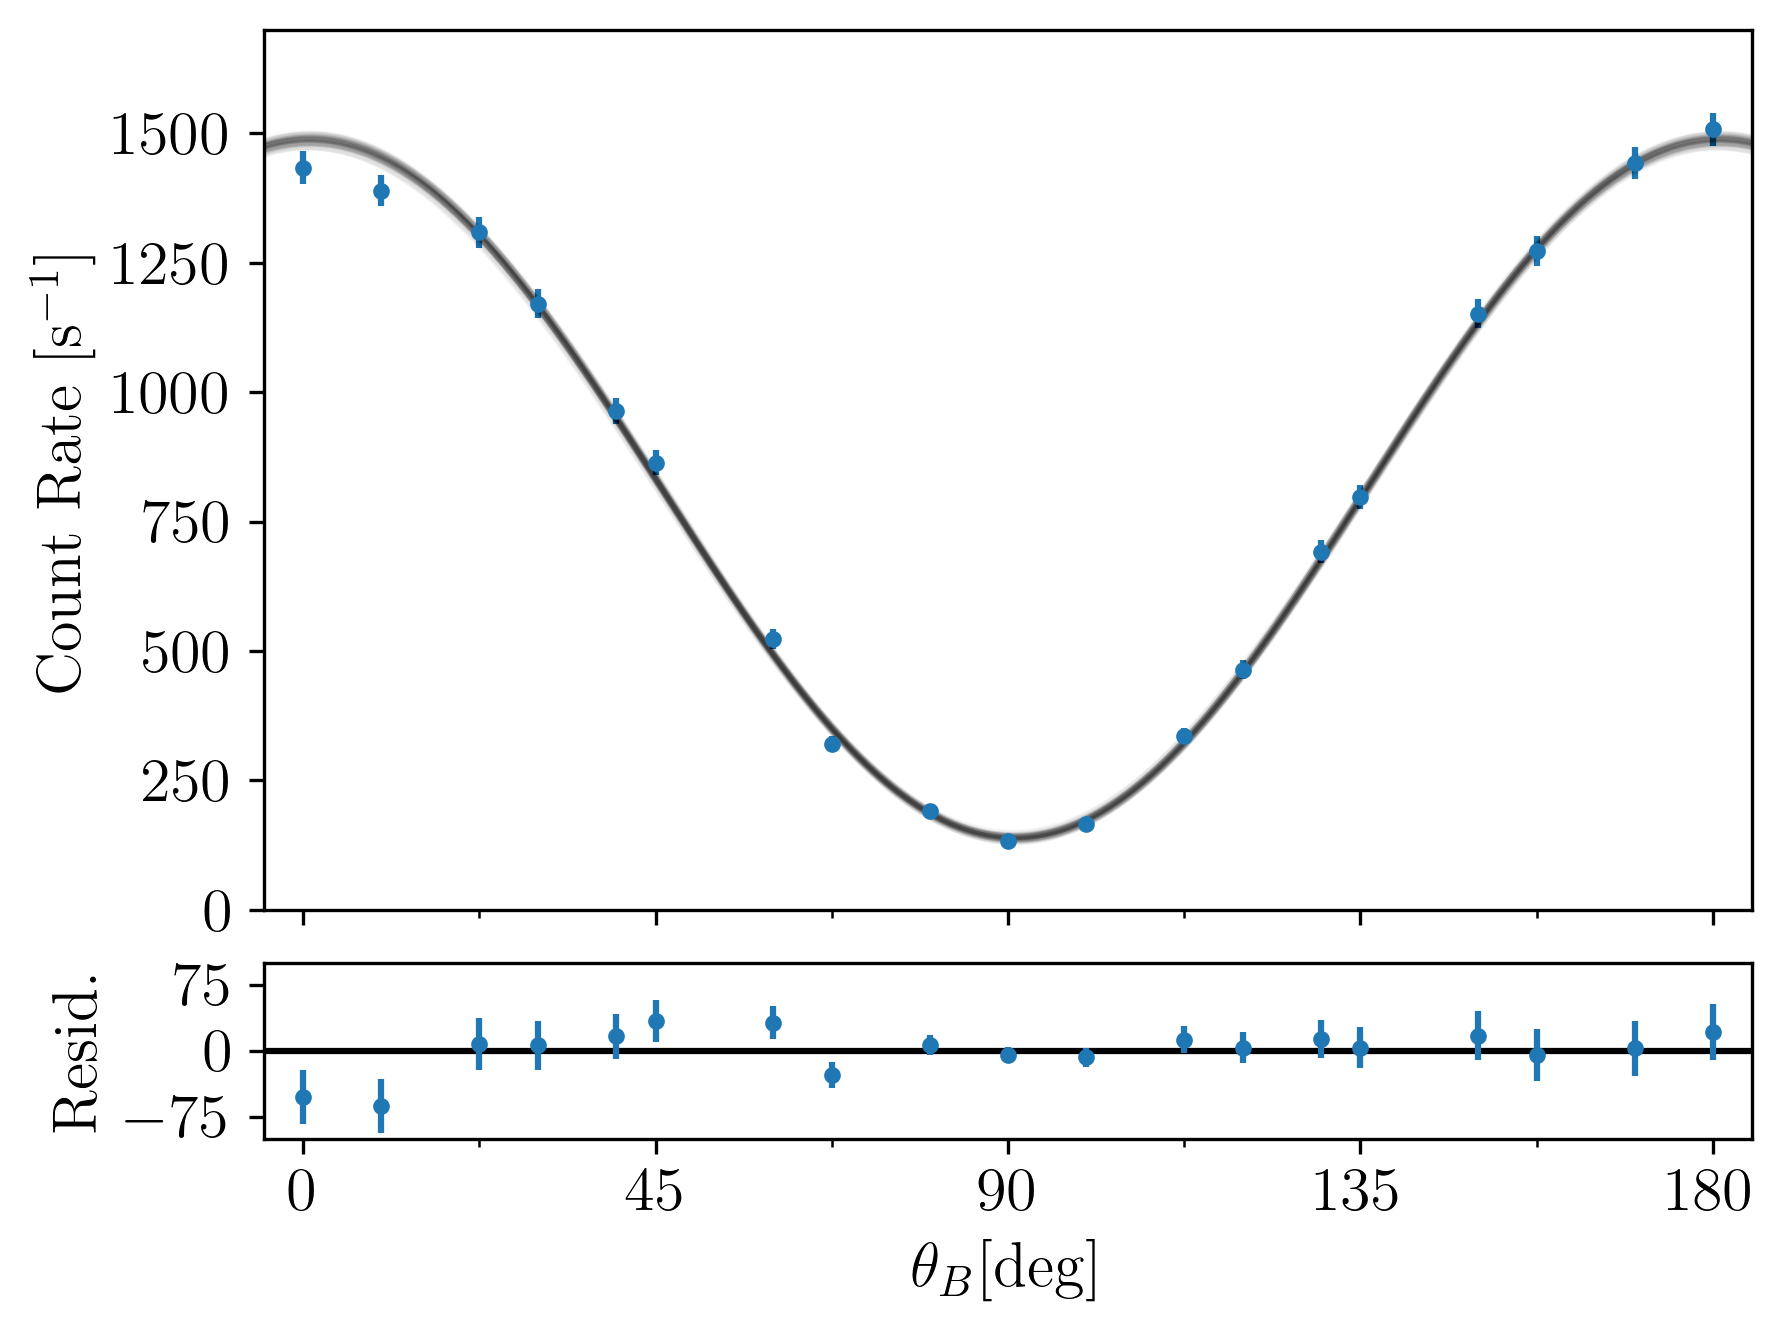

In [31]:
chain = sampler.get_chain(discard=int(np.max(autocorr_time*4)), flat=True)
fig, axs = plt.subplots(2, dpi = 300, height_ratios = [5, 1], sharex = True)

axs[0].errorbar(df['ANGLE'], df['COIN_RATE'], df["E_COIN_RATE"] * np.sqrt(chi_sq_mcmc), ls="", marker=".")
x = np.linspace(-5, 185, 500)
#ax.plot(x, model(x, *np.median(chain, axis = 0)))
for i in range(100):
    axs[0].plot(x, model(x, *chain[-i]), color = "black", alpha = 0.01)
axs[0].set_ylim(0, 1700)
axs[0].set_xlim(-5, 185)
axs[1].set_xlabel("$\\theta_B [\\deg]$")
axs[0].set_ylabel("Count Rate $[\\text{s}^{-1}]$")
plt.subplots_adjust(hspace=.1)

axs[1].set_xticks(np.linspace(0, 180, 5))
axs[1].set_xticks(np.linspace(22.5, 157.5, 4), minor=True)
axs[1].set_ylabel("Resid.")
axs[1].set_yticks([-75, 0, 75])
axs[1].set_ylim([-100,100])
axs[1].axhline(0, color = "black")
axs[1].errorbar(df['ANGLE'], df['COIN_RATE'] - model(df["ANGLE"], *np.median(chain, axis = 0)), df["E_COIN_RATE"] * np.sqrt(chi_sq_mcmc), ls="", marker=".")
plt.savefig("figures/residual_plot.png", bbox_inches = "tight")